# mtcars and Synthetic Data: Hierarchical Clustering

## Project Overview

This notebook explores hierarchical clustering through a real tabular dataset and two small two-dimensional examples.

The workflow combines SciPy dendrogram construction with scikit-learn agglomerative clustering, then computes pairwise Euclidean distance matrices manually to make single-linkage behavior easier to inspect.

### Technical Coverage

- complete-linkage dendrograms
- truncated dendrogram visualization
- agglomerative clustering
- Ward linkage
- average linkage
- Euclidean distance
- Manhattan distance
- direct label-agreement calculation
- manual pairwise Euclidean distance matrices
- single-linkage clustering
- synthetic two-dimensional clustering examples

## 1. Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## 2. mtcars Data

Four numerical vehicle attributes are used for clustering:

- miles per gallon (`mpg`)
- displacement (`disp`)
- horsepower (`hp`)
- weight (`wt`)

The transmission indicator `am` is retained only as a reference label for the direct label-agreement calculations shown later.

In [3]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

cars = pd.read_csv(io.BytesIO(uploaded["mtcars.csv"]))

cars.head()

Saving mtcars.csv to mtcars.csv


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
X = cars[['mpg', 'disp', 'hp', 'wt']].values

y = cars['am'].values
#y = cars.iloc[:,(9)].values

### First Five Feature Vectors

In [5]:
X[0:5]

array([[ 21.   , 160.   , 110.   ,   2.62 ],
       [ 21.   , 160.   , 110.   ,   2.875],
       [ 22.8  , 108.   ,  93.   ,   2.32 ],
       [ 21.4  , 258.   , 110.   ,   3.215],
       [ 18.7  , 360.   , 175.   ,   3.44 ]])

### First Five Reference Labels

In [6]:
y[0:5]

array([1, 1, 1, 0, 0])

## 3. Complete-Linkage Dendrogram

SciPy's `linkage` function is used with complete linkage, followed by a truncated dendrogram showing the final cluster-merging structure.

In [7]:
Z = linkage(X, method='complete') #method='single'

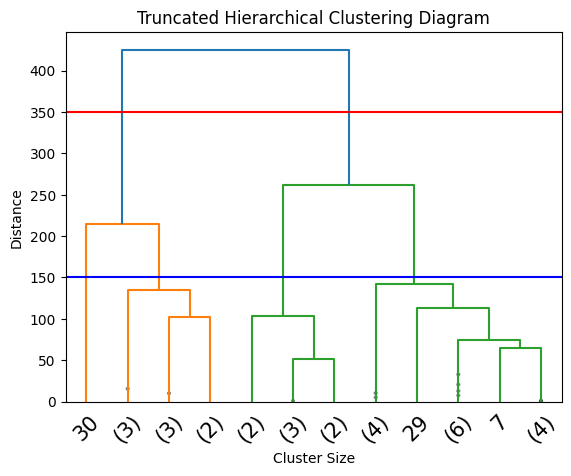

In [8]:
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=45, leaf_font_size=15, show_contracted=True)

plt.title('Truncated Hierarchical Clustering Diagram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')

plt.axhline(y=350, color='red')
plt.axhline(y=150, color='blue')
plt.show()

## 4. Agglomerative Clustering

Three distance/linkage configurations are evaluated with two requested clusters.

> Cluster identifiers are arbitrary. The accuracy values below are direct numerical agreement with `am`, exactly as calculated by the implementation; they should not be interpreted as a permutation-invariant clustering metric.

### Ward Linkage with Euclidean Distance

In [9]:
k = 2

Hclustering = AgglomerativeClustering(
    n_clusters=k,
    metric="euclidean",
    linkage="ward"
)
Hclustering.fit(X)

metrics.accuracy_score(y, Hclustering.labels_)

0.78125

### Cluster Assignments

In [10]:
Hclustering.labels_

array([1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1])

### Average Linkage with Euclidean Distance

In [11]:
Hclustering = AgglomerativeClustering(
    n_clusters=k,
    metric="euclidean",
    linkage="average"
)
Hclustering.fit(X)

metrics.accuracy_score(y, Hclustering.labels_)

0.78125

### Average Linkage with Manhattan Distance

In [12]:
Hclustering = AgglomerativeClustering(
    n_clusters=k,
    metric="manhattan",
    linkage="average"
)
Hclustering.fit(X)

metrics.accuracy_score(y, Hclustering.labels_)

0.71875

### Saved Direct Label-Agreement Results

| Configuration | Agreement |
|---|---:|
| Ward + Euclidean | 0.78125 |
| Average + Euclidean | 0.78125 |
| Average + Manhattan | 0.71875 |

## 5. Synthetic Example A: Pairwise Distances and Single Linkage

Six two-dimensional observations are used to compute a Euclidean distance matrix manually before constructing a single-linkage dendrogram.

In [13]:
data = np.array([[0.40,0.53],[0.22,0.38],[0.35,0.32],[0.26,0.19],[0.08,0.41],[0.45,0.30]])

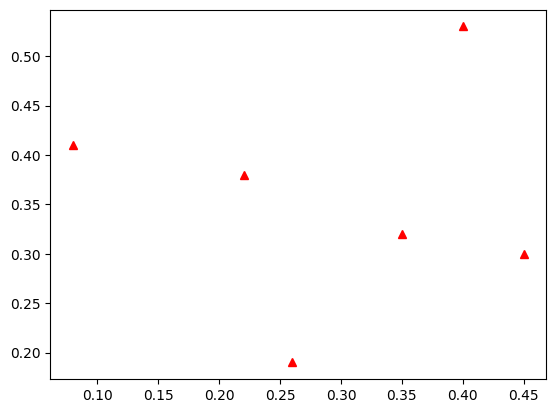

In [14]:
plt.plot(data[:,0], data[:,1], 'r^')
plt.show()

### Euclidean Distance Function

In [15]:
def mydist(p1, p2):
    d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
    return d

### Pairwise Distance Matrix

In [16]:
dist_mat = np.zeros((6,6))
dist_mat.shape

for i in range(6):
    for j in range(6):
        d = mydist(data[i], data[j])
        dist_mat[i,j] = round(d,3)

In [17]:
dist_mat

array([[0.   , 0.234, 0.216, 0.368, 0.342, 0.235],
       [0.234, 0.   , 0.143, 0.194, 0.143, 0.244],
       [0.216, 0.143, 0.   , 0.158, 0.285, 0.102],
       [0.368, 0.194, 0.158, 0.   , 0.284, 0.22 ],
       [0.342, 0.143, 0.285, 0.284, 0.   , 0.386],
       [0.235, 0.244, 0.102, 0.22 , 0.386, 0.   ]])

### Single-Linkage Hierarchy

In [18]:
Z = linkage(data, 'single')

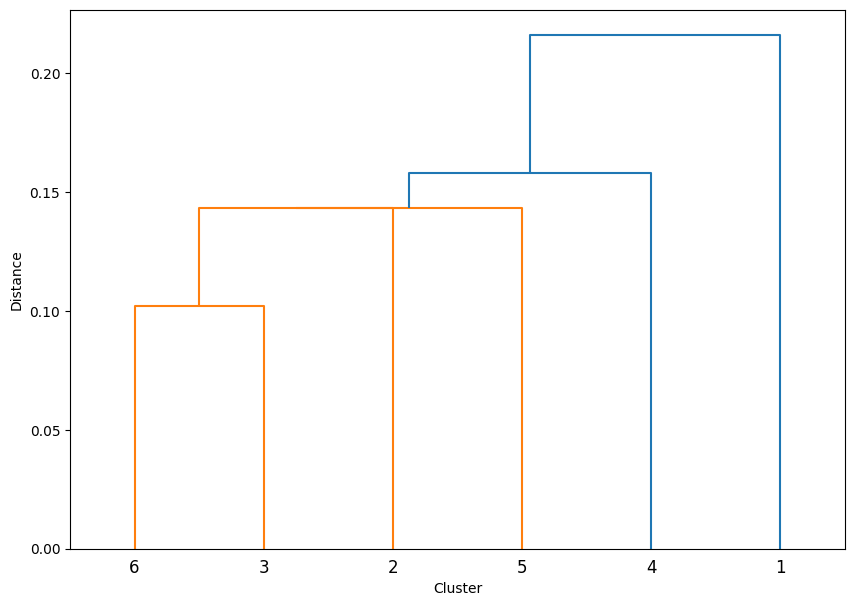

In [19]:
linked  = linkage(data, 'single')
labellist = range(1,7)

plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=labellist,
           distance_sort='descending',
           show_leaf_counts=True)

plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()


## 6. Synthetic Example B: Two Separated Groups

A second six-point dataset contains two clearly separated spatial groups. The same Euclidean-distance calculation and single-linkage hierarchy are examined.

In [20]:
data = np.array([[24,10],[10,15],[15,12],[80,91],[71,80],[60,78]])

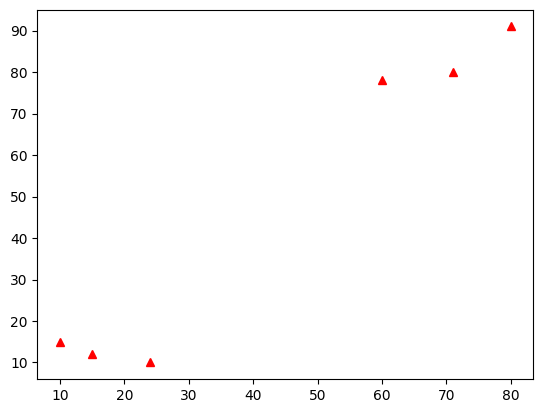

In [21]:
plt.plot(data[:,0], data[:,1], 'r^')
plt.show()

### Single-Linkage Dendrogram

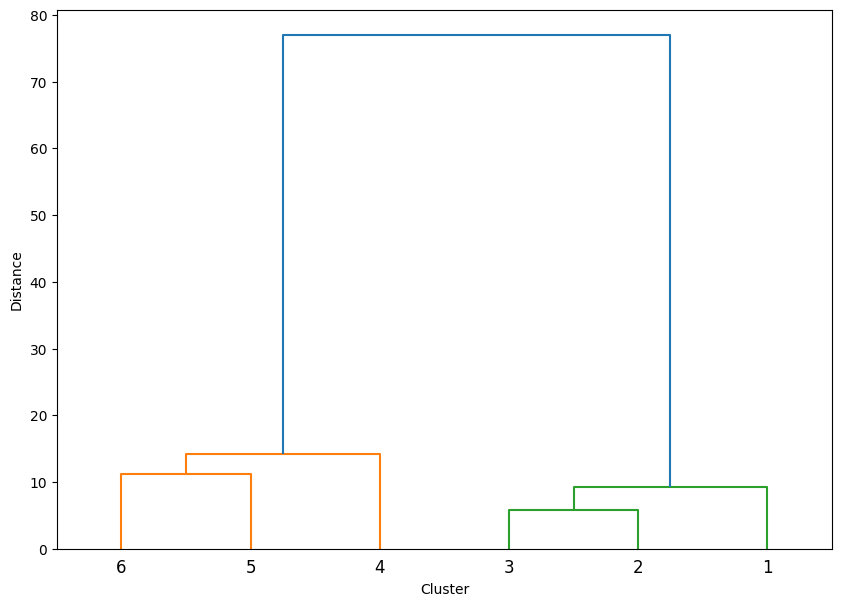

In [22]:
linked  = linkage(data, 'single', metric='euclidean', optimal_ordering=False)
labellist = range(1,7)

plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=labellist,
           distance_sort='descending',
           show_leaf_counts=True)

plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

### Pairwise Distance Matrix

In [23]:
dist_mat = np.zeros((6,6))
dist_mat.shape

for i in range(6):
    for j in range(6):
        d = mydist(data[i], data[j])
        dist_mat[i,j] = round(d,3)

In [24]:
dist_mat

array([[  0.   ,  14.866,   9.22 ,  98.473,  84.315,  76.942],
       [ 14.866,   0.   ,   5.831, 103.325,  89.14 ,  80.43 ],
       [  9.22 ,   5.831,   0.   , 102.303,  88.091,  79.881],
       [ 98.473, 103.325, 102.303,   0.   ,  14.213,  23.854],
       [ 84.315,  89.14 ,  88.091,  14.213,   0.   ,  11.18 ],
       [ 76.942,  80.43 ,  79.881,  23.854,  11.18 ,   0.   ]])

## 7. Key Findings

- Hierarchical clustering can be inspected both numerically through linkage distances and visually through dendrograms.
- Complete, Ward, and average linkage define cluster merging differently.
- Distance choice can change the resulting agglomerative partition.
- The manually computed distance matrices make the nearest-pair relationships in single linkage explicit.
- The second synthetic example shows how large between-group distances create a clear high-level separation in the dendrogram.